This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction.

In [1]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
#
#import yfinance as yf
#df_HSI = yf.download("^HSI", start="2022-01-01", end="2023-01-01" ).droplevel('Ticker', axis=1)

company = "^hsi"
df_HKstock = yf.download("^hsi", start="2021-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,27472.810547,27502.830078,27079.240234,27087.130859,2870400000
2021-01-05,27649.859375,27690.210938,27150.380859,27281.339844,3282500000
2021-01-06,27692.300781,27756.429688,27389.779297,27613.339844,3079400000
2021-01-07,27548.519531,27752.359375,27457.470703,27715.939453,3775100000
2021-01-08,27878.220703,27920.769531,27538.199219,27630.029297,5667300000
...,...,...,...,...,...
2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000


In [4]:
# Save to CSV
df_HKstock.to_csv('^hsi.csv')

In [5]:
#
df_source = pd.read_csv("^hsi.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2021-01-04,27472.810547,27502.830078,27079.240234,27087.130859,2870400000
1,2021-01-05,27649.859375,27690.210938,27150.380859,27281.339844,3282500000
2,2021-01-06,27692.300781,27756.429688,27389.779297,27613.339844,3079400000
3,2021-01-07,27548.519531,27752.359375,27457.470703,27715.939453,3775100000
4,2021-01-08,27878.220703,27920.769531,27538.199219,27630.029297,5667300000
...,...,...,...,...,...,...
1223,2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
1224,2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
1225,2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000
1226,2025-12-30,25854.599609,25930.220703,25611.230469,25636.400391,3138100000


In [27]:
#
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2021-01-04,27472.810547,27502.830078,27079.240234,27087.130859,2870400000
1,2021-01-05,27649.859375,27690.210938,27150.380859,27281.339844,3282500000
2,2021-01-06,27692.300781,27756.429688,27389.779297,27613.339844,3079400000
3,2021-01-07,27548.519531,27752.359375,27457.470703,27715.939453,3775100000
4,2021-01-08,27878.220703,27920.769531,27538.199219,27630.029297,5667300000
...,...,...,...,...,...,...
1223,2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
1224,2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
1225,2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000
1226,2025-12-30,25854.599609,25930.220703,25611.230469,25636.400391,3138100000


In [6]:
df_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1228 non-null   str    
 1   Close   1228 non-null   float64
 2   High    1228 non-null   float64
 3   Low     1228 non-null   float64
 4   Open    1228 non-null   float64
 5   Volume  1228 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 57.7 KB


In [7]:
df_source = df_source.set_index('Date', )     # set Date as index
df_source.info()

<class 'pandas.DataFrame'>
Index: 1228 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1228 non-null   float64
 1   High    1228 non-null   float64
 2   Low     1228 non-null   float64
 3   Open    1228 non-null   float64
 4   Volume  1228 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 57.6+ KB


In [8]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,27472.810547,27502.830078,27079.240234,27087.130859,2870400000
2021-01-05,27649.859375,27690.210938,27150.380859,27281.339844,3282500000
2021-01-06,27692.300781,27756.429688,27389.779297,27613.339844,3079400000
2021-01-07,27548.519531,27752.359375,27457.470703,27715.939453,3775100000
2021-01-08,27878.220703,27920.769531,27538.199219,27630.029297,5667300000
...,...,...,...,...,...
2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000


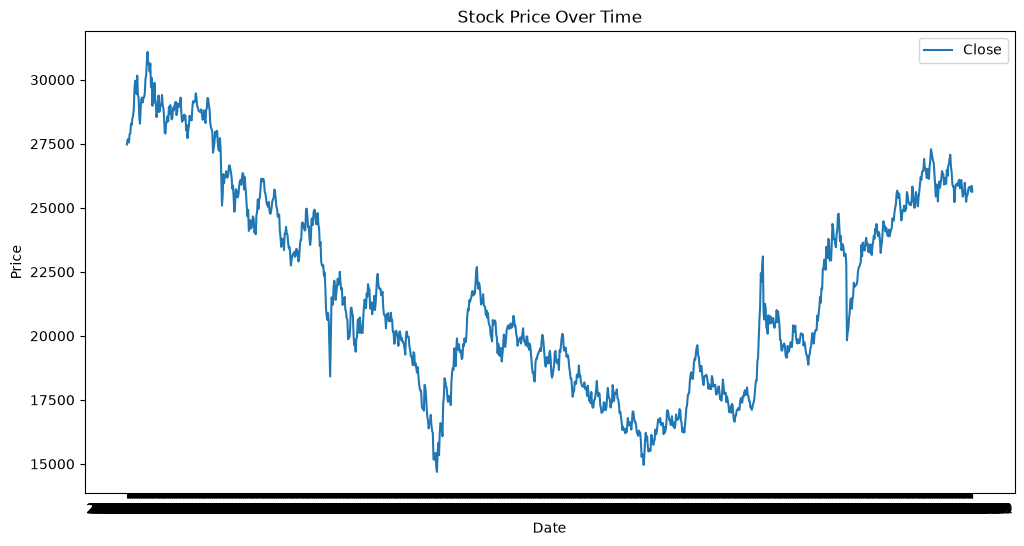

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close')
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

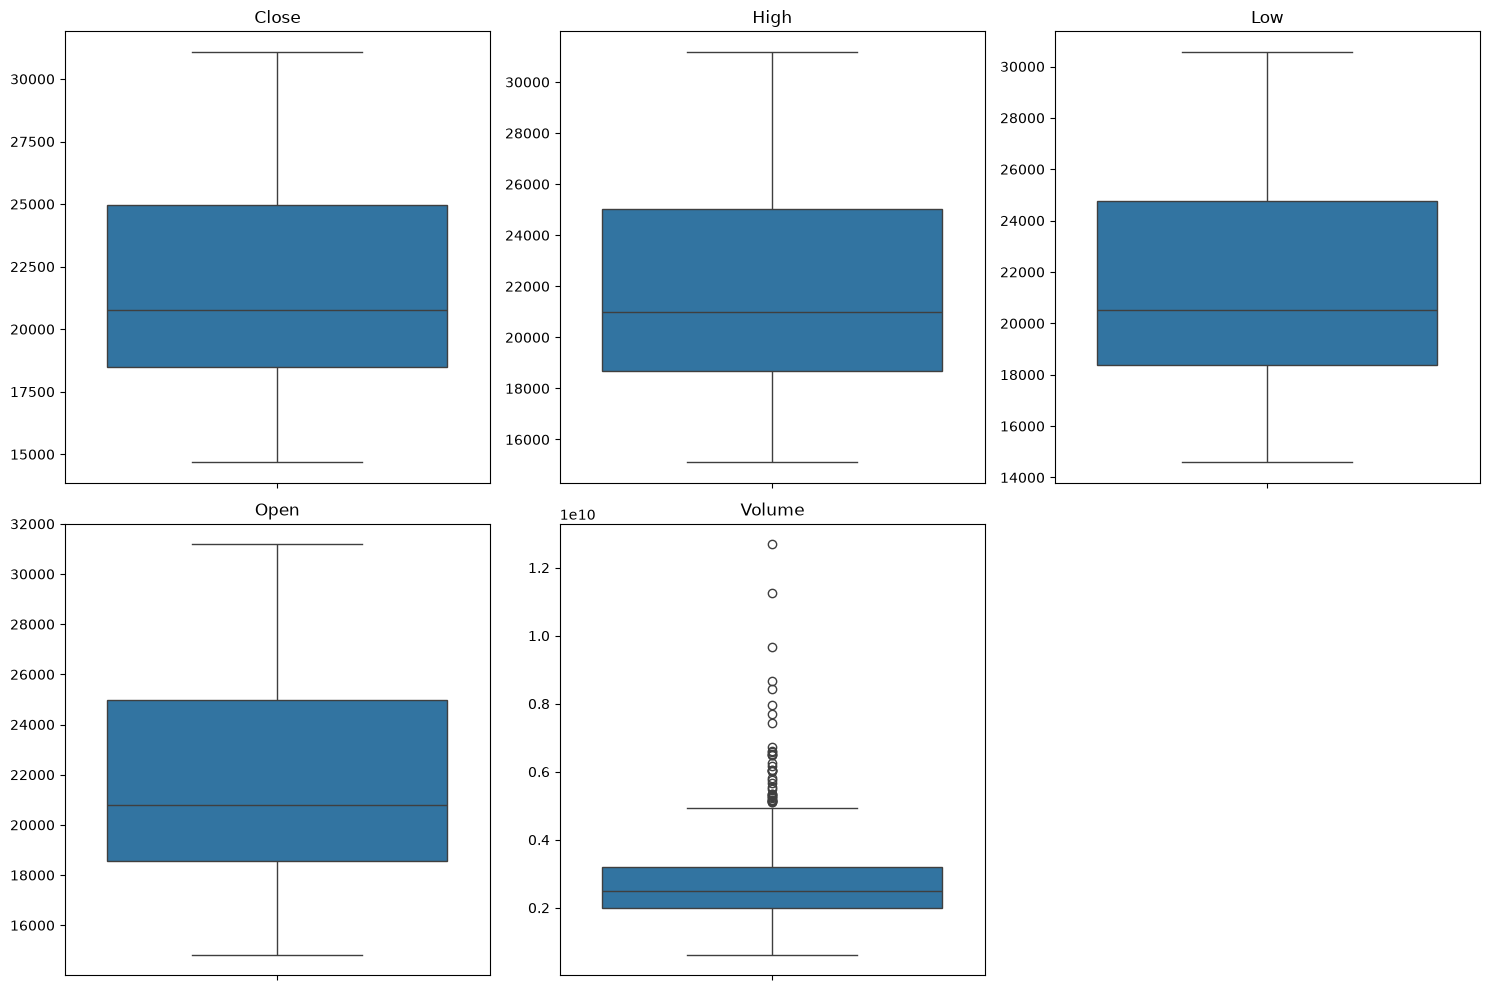

In [10]:
# Check outliers and variations
#import math
#import matplotlib.pyplot as plt
#import seaborn as sns
num_cols = 3
num_features = len(df.columns)
num_rows = math.ceil(num_features / num_cols)

fig = plt.figure(figsize=(15, num_rows * 5))

for i, x in enumerate(df.columns, start=1):
    plt.subplot(num_rows, num_cols, i)
    ax = sns.boxplot(df[x])
    ax.set(xlabel=None)
    plt.title(str(x), loc='center')
    plt.xlabel(None)
    plt.ylabel(None)

plt.tight_layout()
plt.show()

Box plots apply to identify outliers; may identify anomalous trading days or incorrect data points

In [11]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [12]:
# Handling if missing values
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,27472.810547,27502.830078,27079.240234,27087.130859,2870400000
2021-01-05,27649.859375,27690.210938,27150.380859,27281.339844,3282500000
2021-01-06,27692.300781,27756.429688,27389.779297,27613.339844,3079400000
2021-01-07,27548.519531,27752.359375,27457.470703,27715.939453,3775100000
2021-01-08,27878.220703,27920.769531,27538.199219,27630.029297,5667300000
...,...,...,...,...,...
2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000


In [13]:
# Calculate moving averages and daily returns
df['7-day MA'] = df['Close'].rolling(window=7).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [14]:
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,7-day MA,50-day MA,Daily Return
Date,,,,,,,,
2021-01-04,27472.810547,27502.830078,27079.240234,27087.130859,2870400000,NaN,NaN,NaN
2021-01-05,27649.859375,27690.210938,27150.380859,27281.339844,3282500000,NaN,NaN,0.006445
2021-01-06,27692.300781,27756.429688,27389.779297,27613.339844,3079400000,NaN,NaN,0.001535
2021-01-07,27548.519531,27752.359375,27457.470703,27715.939453,3775100000,NaN,NaN,-0.005192
2021-01-08,27878.220703,27920.769531,27538.199219,27630.029297,5667300000,NaN,NaN,0.011968
2021-01-11,27908.220703,28176.650391,27794.810547,28003.980469,4366100000,NaN,NaN,0.001076
2021-01-12,28276.750000,28276.750000,27781.419922,27894.289062,3399600000,27775.240234,NaN,0.013205
2021-01-13,28235.599609,28414.539062,28136.640625,28309.320312,3559400000,27884.210100,NaN,-0.001455
2021-01-14,28496.859375,28510.919922,28280.089844,28408.119141,3205600000,28005.210100,NaN,0.009253


In [15]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,7-day MA,50-day MA,Daily Return
Date,,,,,,,,
2021-03-16,29027.689453,29118.619141,28872.400391,29036.820312,2351600000,28886.908482,29197.730742,0.006726
2021-03-17,29034.119141,29180.009766,28780.230469,28992.240234,1901300000,28957.378348,29228.956914,0.000222
2021-03-18,29405.720703,29596.580078,29317.609375,29317.609375,2113700000,29047.734096,29264.074141,0.012799
2021-03-19,28990.939453,29271.400391,28737.539062,29158.480469,3814400000,29059.651228,29290.046914,-0.014105
2021-03-22,28885.339844,29139.070312,28801.089844,28801.089844,2065800000,28988.184152,29316.783320,-0.003643
...,...,...,...,...,...,...,...,...
2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000,25585.377232,25954.808828,-0.001071
2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000,25612.527065,25962.360430,0.001738
2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000,25669.644252,25956.853047,-0.007115


Stock price exhibits upward trend with fluctuations; as if as there are periods of high volatility, suggesting possible external market influences

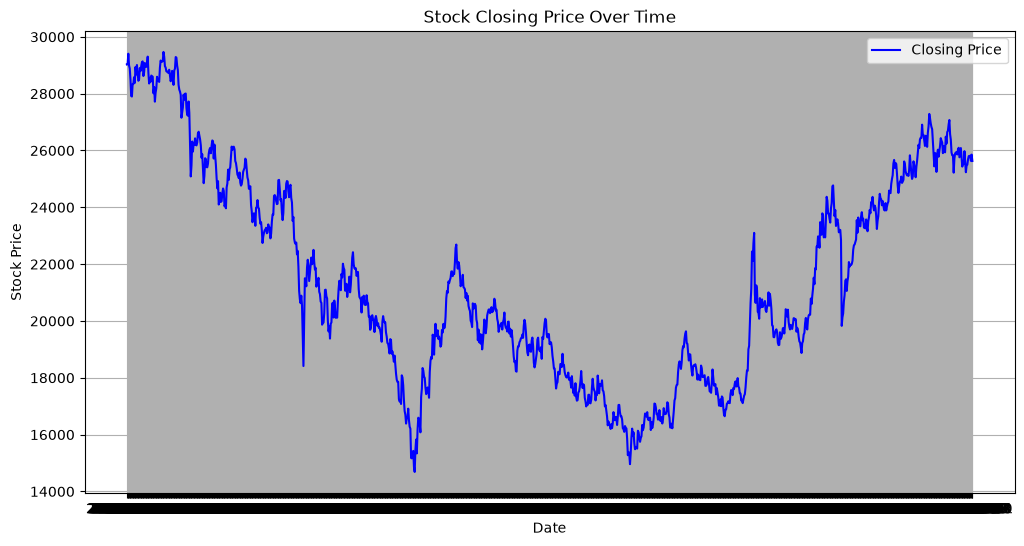

In [16]:
# EDA - explore trends and patterns
plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Closing Price Over Time")  
plt.plot(df['Close'], label="Closing Price", color="blue")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()

7-day MA captures short-term fluctuations while the 50-day MA provides a smoother long-term trend

Sharp deviations between moving averages may indicate trend reversals

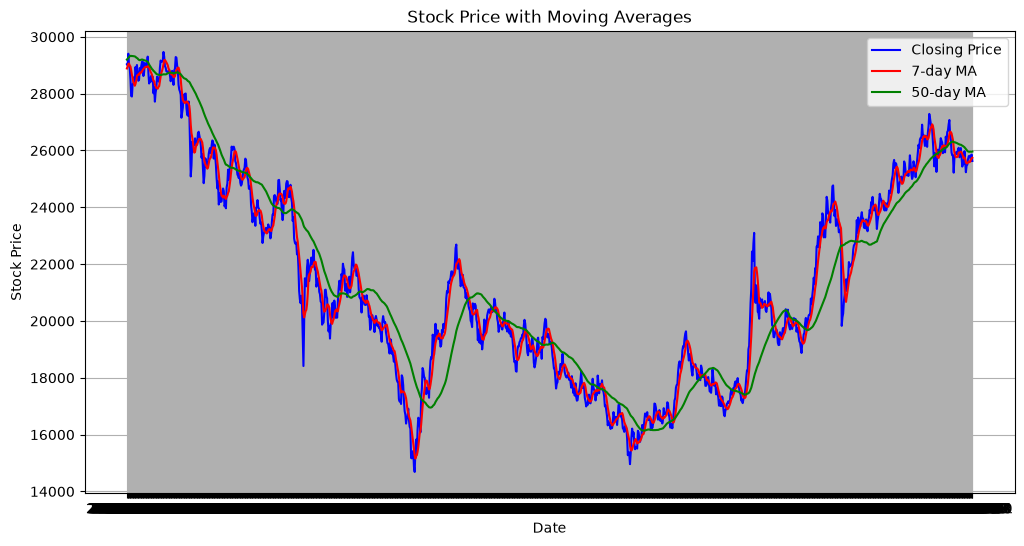

In [17]:
# Smoothen short-term fluctuations with moving averages
plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Price with Moving Averages")
plt.plot(df['Close'], label="Closing Price", color="blue")
plt.plot(df['7-day MA'], label="7-day MA", color="red")
plt.plot(df['50-day MA'], label="50-day MA", color="green")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()


Large spikes indicate high volatility days

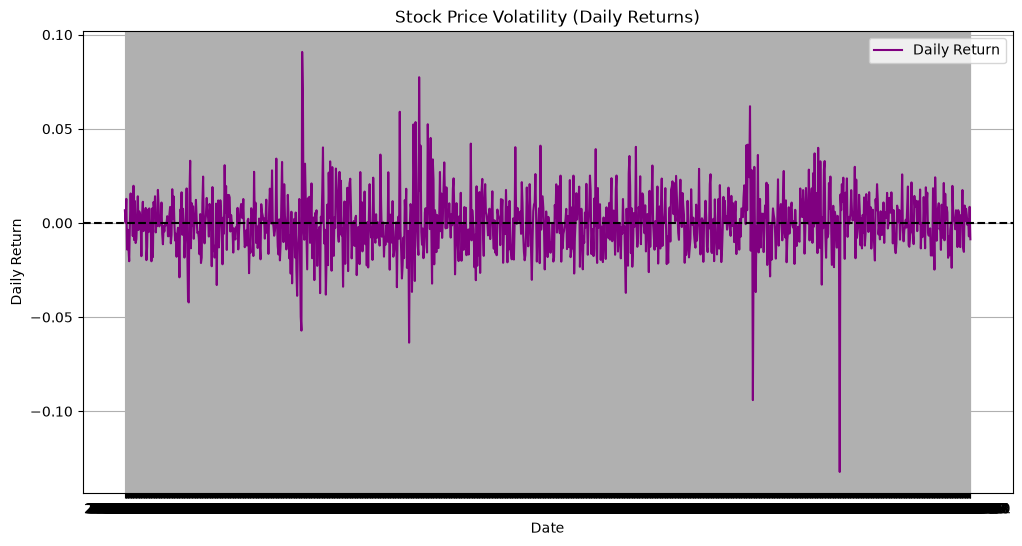

In [18]:
# Analyse Volatility
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Stock Price Volatility (Daily Returns)")
plt.plot(df['Daily Return'], label="Daily Return", color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

In [19]:
# Normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [20]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -2.0881750271448483
p-value: 0.24929598996609847
The series is not stationary.


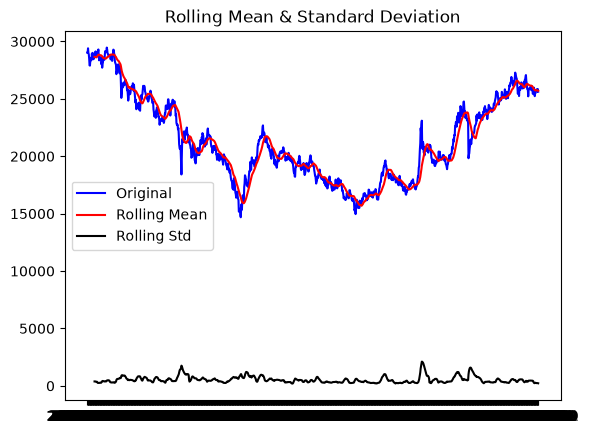

Results of Dickey-Fuller Test:
Test Statistic                   -2.088175
p-value                           0.249296
#Lags Used                        2.000000
Number of Observations Used    1176.000000
Critical Value (1%)              -3.435923
Critical Value (5%)              -2.864001
Critical Value (10%)             -2.568080
dtype: float64


In [21]:
#... LSTM - test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

The p-value is greater than the 5% critical value, so the null hypothesis cannot be rejected.

Regarding the test statistic used in the augmented Dickey-Tuller statistic, it is a negative number. The more negative it is, the stronger the rejection of the hypothesis that there is a unit root at some level of confidence.


# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

<Figure size 640x480 with 0 Axes>

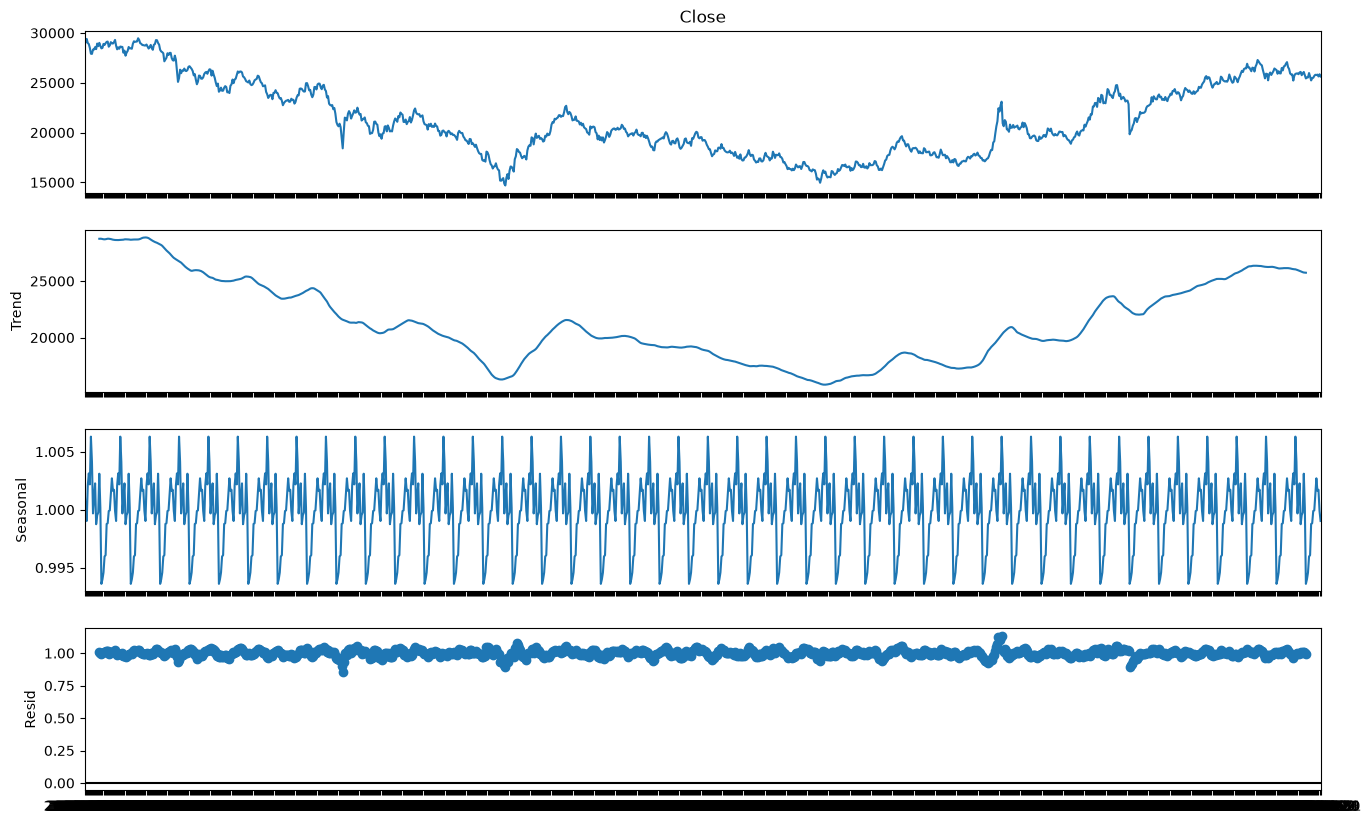

In [22]:
#...
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

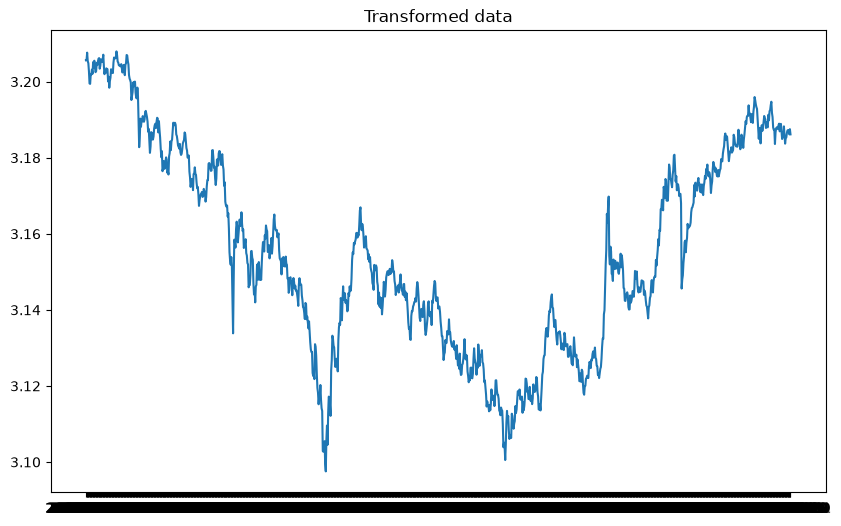

In [23]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

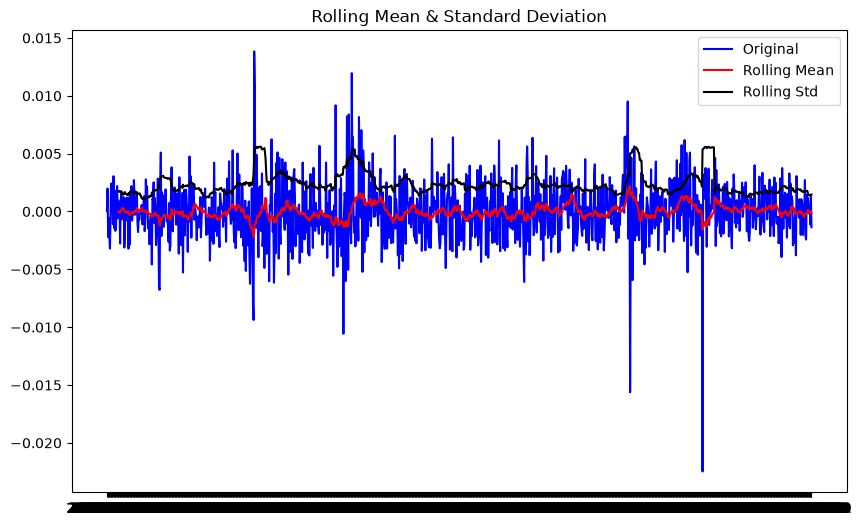

Results of Dickey-Fuller Test:
Test Statistic                  -25.356895
p-value                           0.000000
#Lags Used                        1.000000
Number of Observations Used    1176.000000
Critical Value (1%)              -3.435923
Critical Value (5%)              -2.864001
Critical Value (10%)             -2.568080
dtype: float64


In [24]:
#... clssical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

In [25]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

# choose the number of days on which to base our predictions 
nb_days = 60
n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

#Split the data set between the training set and the test set (20%)
test_days = 90 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

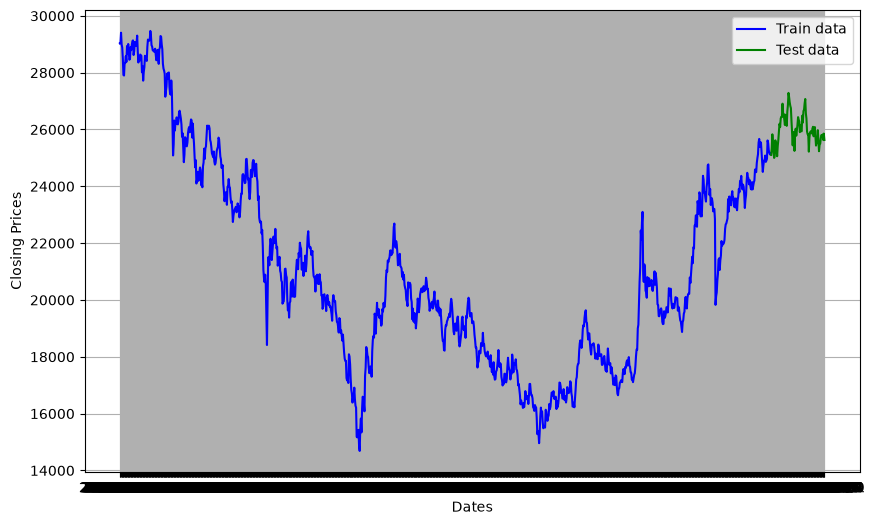

In [26]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [27]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

#
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])    

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 2.0150e-05 - mean_absolute_error: 0.0034
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 7.6228e-06 - mean_absolute_error: 0.0020
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 7.1888e-06 - mean_absolute_error: 0.0020
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 7.0525e-06 - mean_absolute_error: 0.0019
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 7.3553e-06 - mean_absolute_error: 0.0020
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 7.4453e-06 - mean_absolute_error: 0.0020
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 8.8467e-06 - mean_absolute_error: 0.0023
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 7.5547e-06 - mean_absolute_error: 0.0020
Epoch 9/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 7.7166e-06 - mean_absolute_error: 0.0020
Epoch 10/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 7.9319e-06 - mean_absolute_error: 0.0021

In [29]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 4.6899e-06 - mean_absolute_error: 0.0018 
Test MSE: 4.689891738962615e-06
Test MAE: 0.0017611427465453744


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


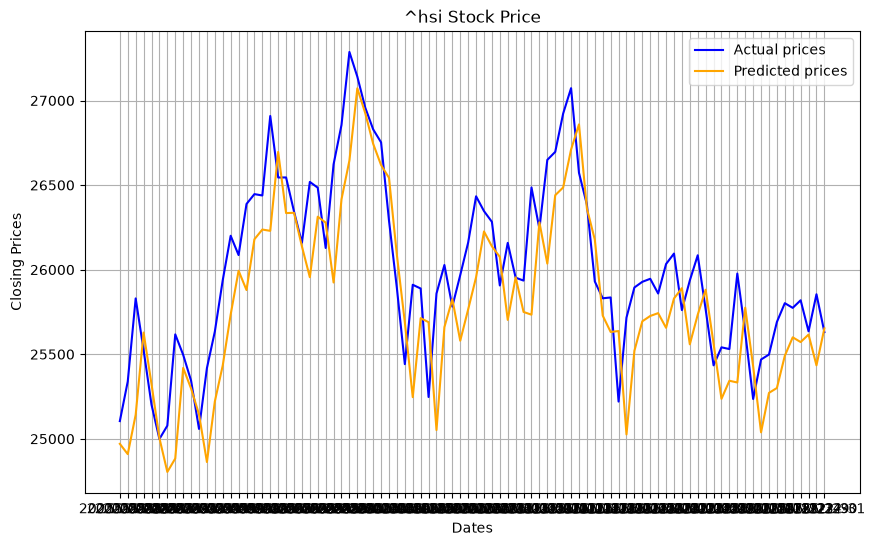

In [30]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

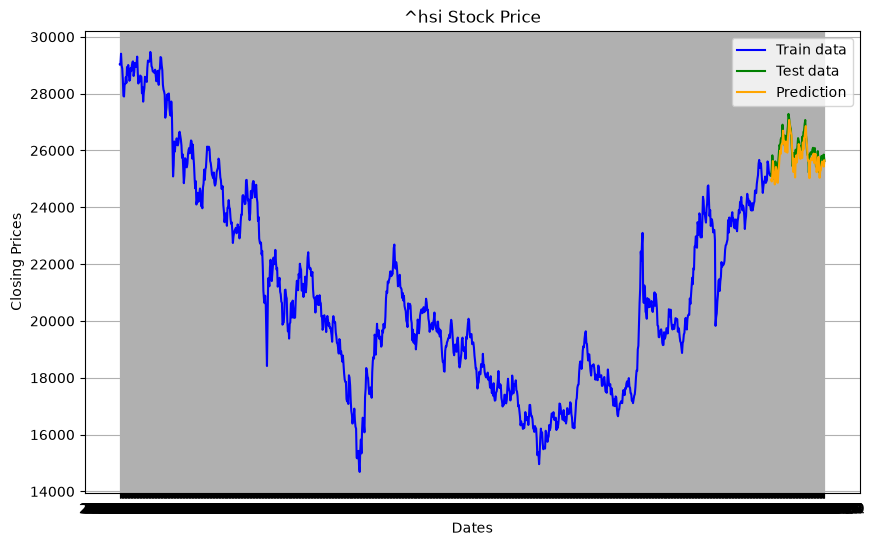

In [31]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [32]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

# Number of days into the future we want to predict
n_steps_out = 10

# choose the number of days on which to base our predictions 
nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

#
#Split the data set between the training set and the test set (20%)
test_days = 90 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [33]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model

#
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,910 (42.62 KB)

 Trainable params: 10,910 (42.62 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#...
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 8.4753e-06 - mean_absolute_error: 0.0022
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 7.5813e-06 - mean_absolute_error: 0.0020
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 7.6143e-06 - mean_absolute_error: 0.0020
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 7.5465e-06 - mean_absolute_error: 0.0020
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 7.5233e-06 - mean_absolute_error: 0.0020
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 7.4437e-06 - mean_absolute_error: 0.0020
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 7.6072e-06 - mean_absolute_error: 0.0020
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 7.4253e-06 - mean_absolute_error: 0.0020
Epoch 9/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 7.5011e-06 - mean_absolute_error: 0.0020
Epoch 10/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 7.5887e-06 - mean_absolute_error: 0.0020

In [35]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 3.2766e-06 - mean_absolute_error: 0.0015 
Test MSE: 3.27658608512138e-06
Test MAE: 0.001477615674957633


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


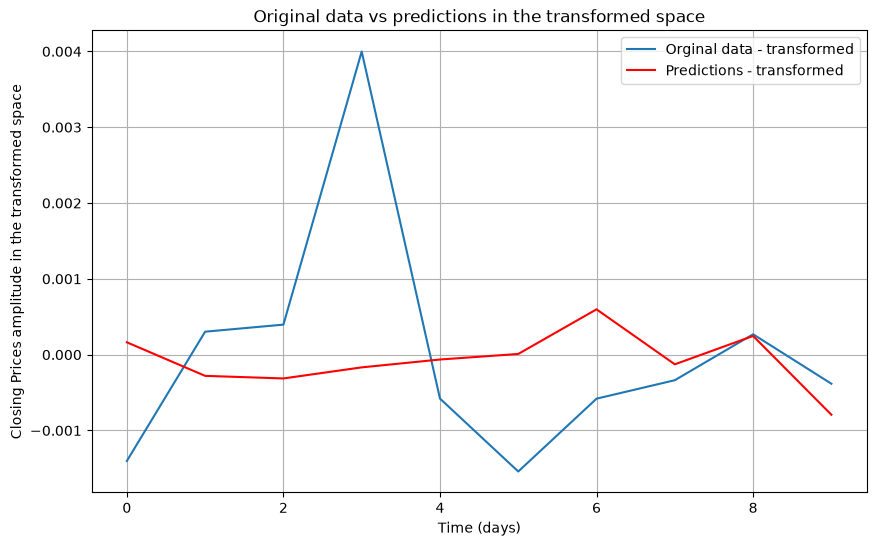

In [36]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')
plt.legend()

In [37]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2025-08-21    3.190857
2025-08-22    3.190577
2025-08-25    3.190263
2025-08-26    3.190096
2025-08-27    3.190032
2025-08-28    3.190041
2025-08-29    3.190639
2025-09-01    3.190512
2025-09-02    3.190758
2025-09-03    3.189966
dtype: float64


In [38]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2025-08-21    26411.776544
2025-08-22    26364.712754
2025-08-25    26311.992238
2025-08-26    26283.865043
2025-08-27    26273.142974
2025-08-28    26274.697189
2025-08-29    26375.126402
2025-09-01    26353.692355
2025-09-02    26395.218957
2025-09-03    26262.133866
dtype: float64


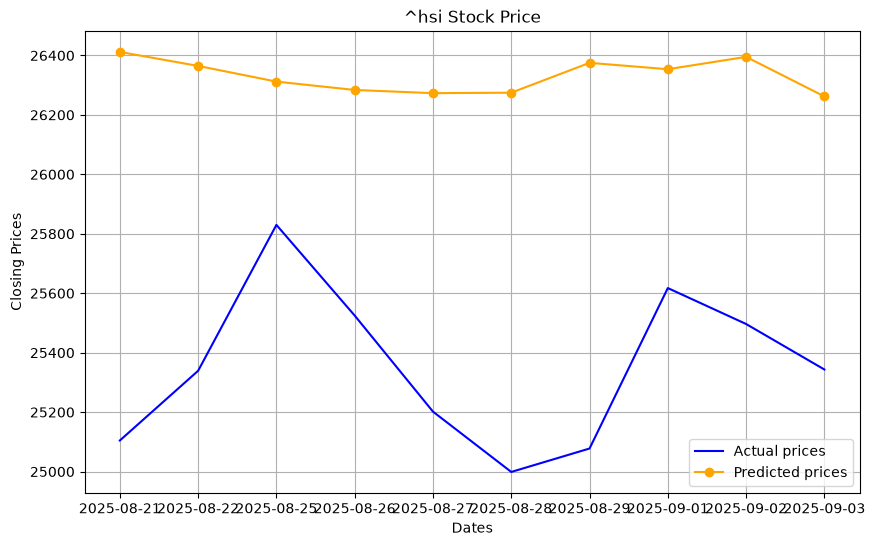

In [39]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [71]:
# Follow from ADF Test if series is stationary
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [72]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [73]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [70]:
#1 LSTM ***SKIP
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=30, batch_size=32)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0120
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0013
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0012
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 9.6364e-04
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.4356e-04
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.8872e-04
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.7975e-04
Epoch 10/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.4007e-04
Epoch 11/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.1111e-04
Epoch 12/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.8941e-04
Epoch 13/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.6201e-04
Epoch 14/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.6167e-04
Epoch 15/30
42/42 ━━━━━━━━━━━━━━━━━

#
LSTM(50 units) → Captures long-term dependencies

Dropout(0.2) → Prevents overfitting

Dense Layers → Produces final prediction

In [74]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=30, batch_size=32)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0244
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0063
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0043
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0043
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0037
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0034
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0037
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0033
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0030
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0032
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0030
Epoch 12/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0026
Epoch 13/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0025
Epoch 14/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0025
Epoch 15/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0032
Epoc

In [75]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


In [76]:
#from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.047261345936146046


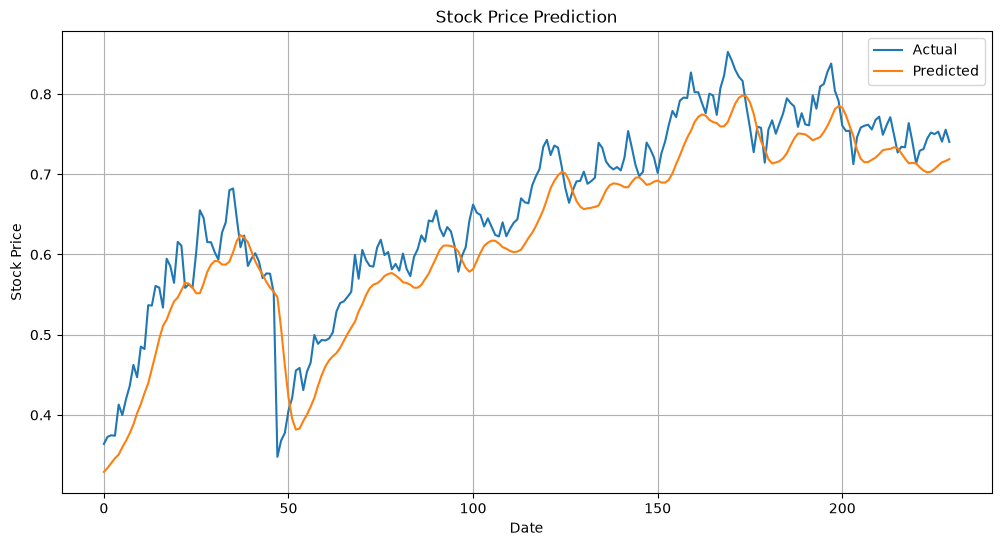

In [77]:
#2
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.